### This notebook demonstrates the post-analysis and visualisation of the PRAS results

In [1]:
import sys
import os

import calendar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
import time
import datetime as datetime
sys.path.append("src")
import numpy as np
from utility import get_shortfall_data, plot_std_error, load_scenario_data
from utility import load_eue_shortfall, get_all_info, reg_load_gen
from utility import plot_yearly_rlg_v1, seasonal_ppmm_stats,get_data_simu 
from utility import flow_result, plot_flow, plot_EUE_lgs

area_code_region = {1:"NNSW", 2:"CNSW", 3:"SNW", 4:"SNSW", 5:"WNV",
                        6:"MEL", 7:"SEV",  8:"NQ", 9:"CQ", 10:"GG",
                        11:"SQ", 12:"NSA", 13:"CSA", 14:"SESA", 15:"TAS"} 

IDIR = os.path.join(os.getcwd(), "../../../../data/ISP_data", "pras_metrics_output", "shortfall_data")
figsize = (25,10)
mpl.rcParams['font.family'] = 'sans-serif'

In [66]:
def load_shortfall_error_data(scenario, IDIR):
    scen_DIR = os.path.join(IDIR, scenario)
    if scenario == "LT_BASE":
        date_run = "23-Apr-26-7-43-52"
    elif scenario == "LT_BEST":
        date_run = "23-Apr-26-7-42-46"
    elif scenario == "LT_WORST":
        date_run = "23-Apr-26-7-42-43"
    elif scenario == "LT_TYP":
        date_run = "23-Apr-26-7-42-45"
  
    data_file = os.path.join(scen_DIR, date_run, "pras_results.json")
    lole_mean, lole_std, eue_mean, eue_std, neue_mean, neue_std, shortfall_data = get_shortfall_data(data_file, area_code_region)
    error_dict = {"lole_mean":lole_mean, "lole_std":lole_std,
             "eue_mean":eue_mean,"eue_std":eue_std,"neue_mean":neue_mean,
             "neue_std":neue_std,"shortfall_data":shortfall_data}
    return error_dict, shortfall_data
    

In [79]:
scenario = "LT_BASE"
print("Scenario chosen: ", scenario)
error_dict, shortfall_data = load_shortfall_error_data(scenario, IDIR)

Scenario chosen:  LT_BASE


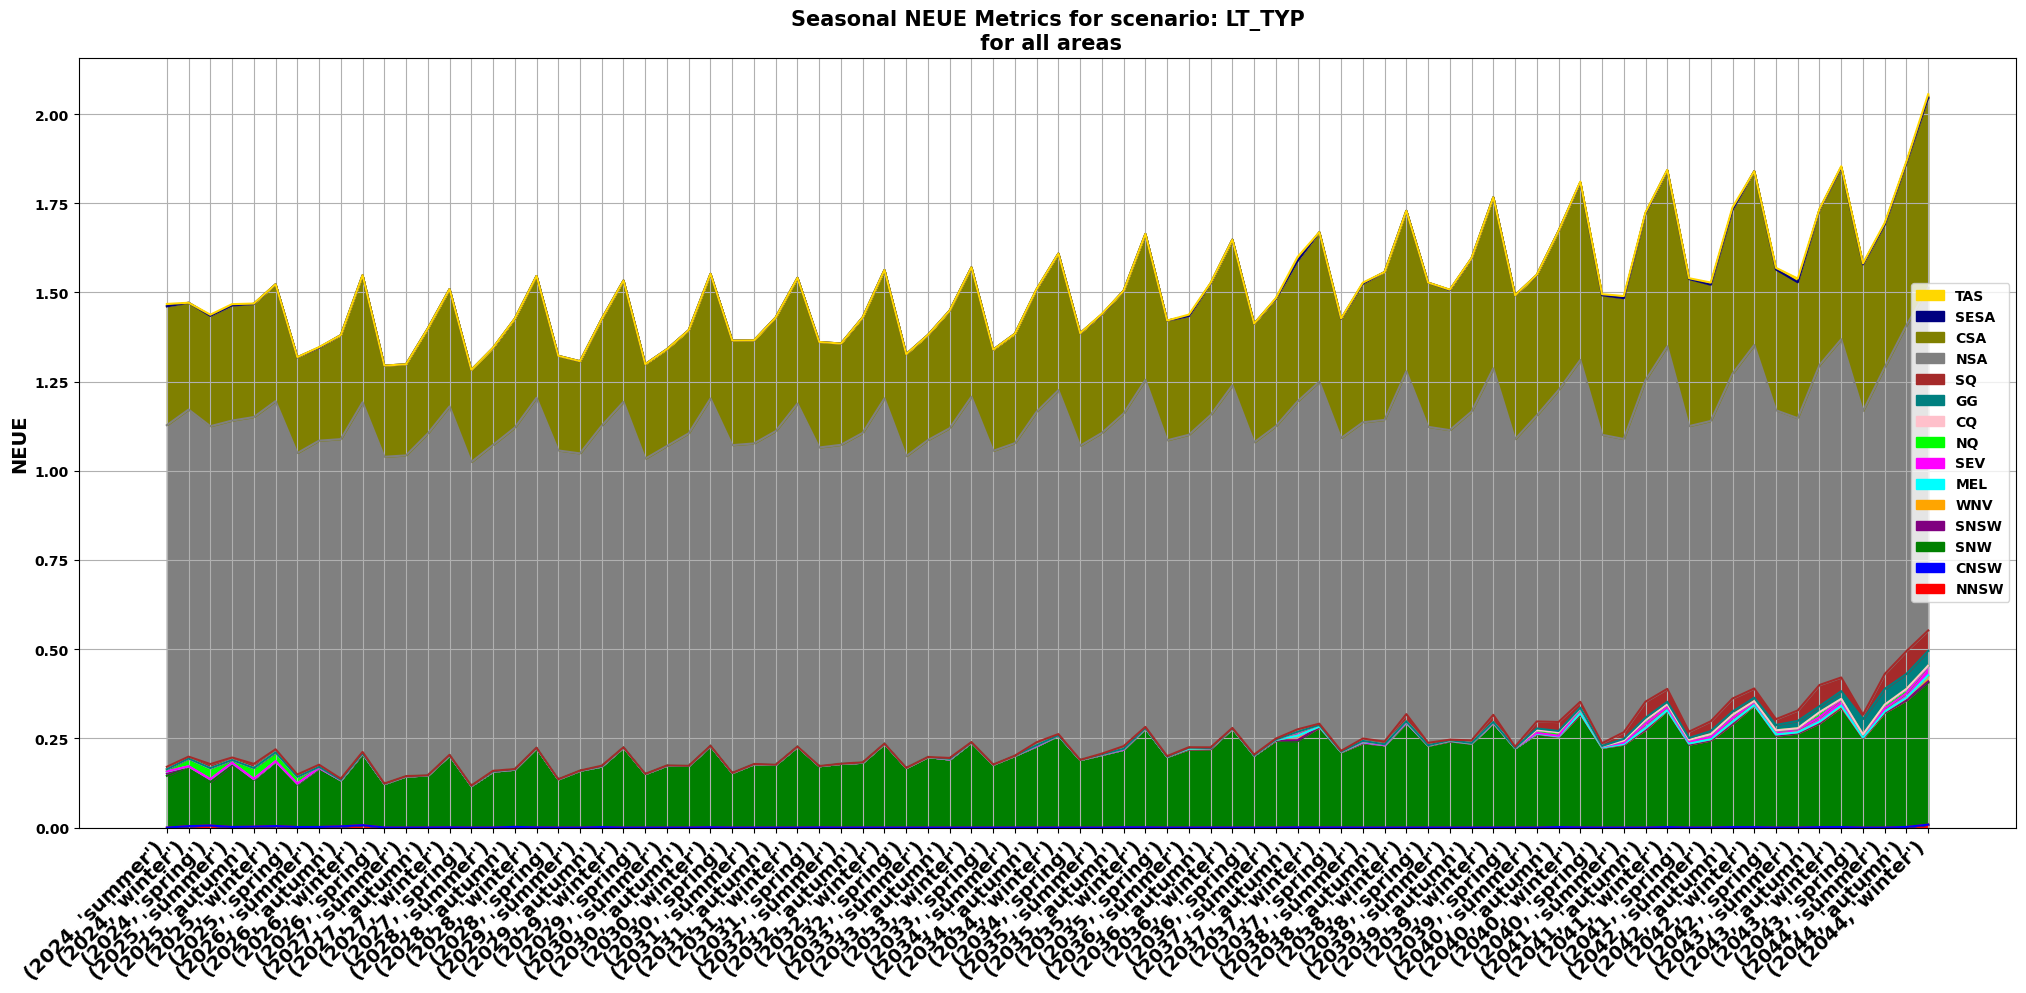

In [75]:
seasonal_data_LT_TYP = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

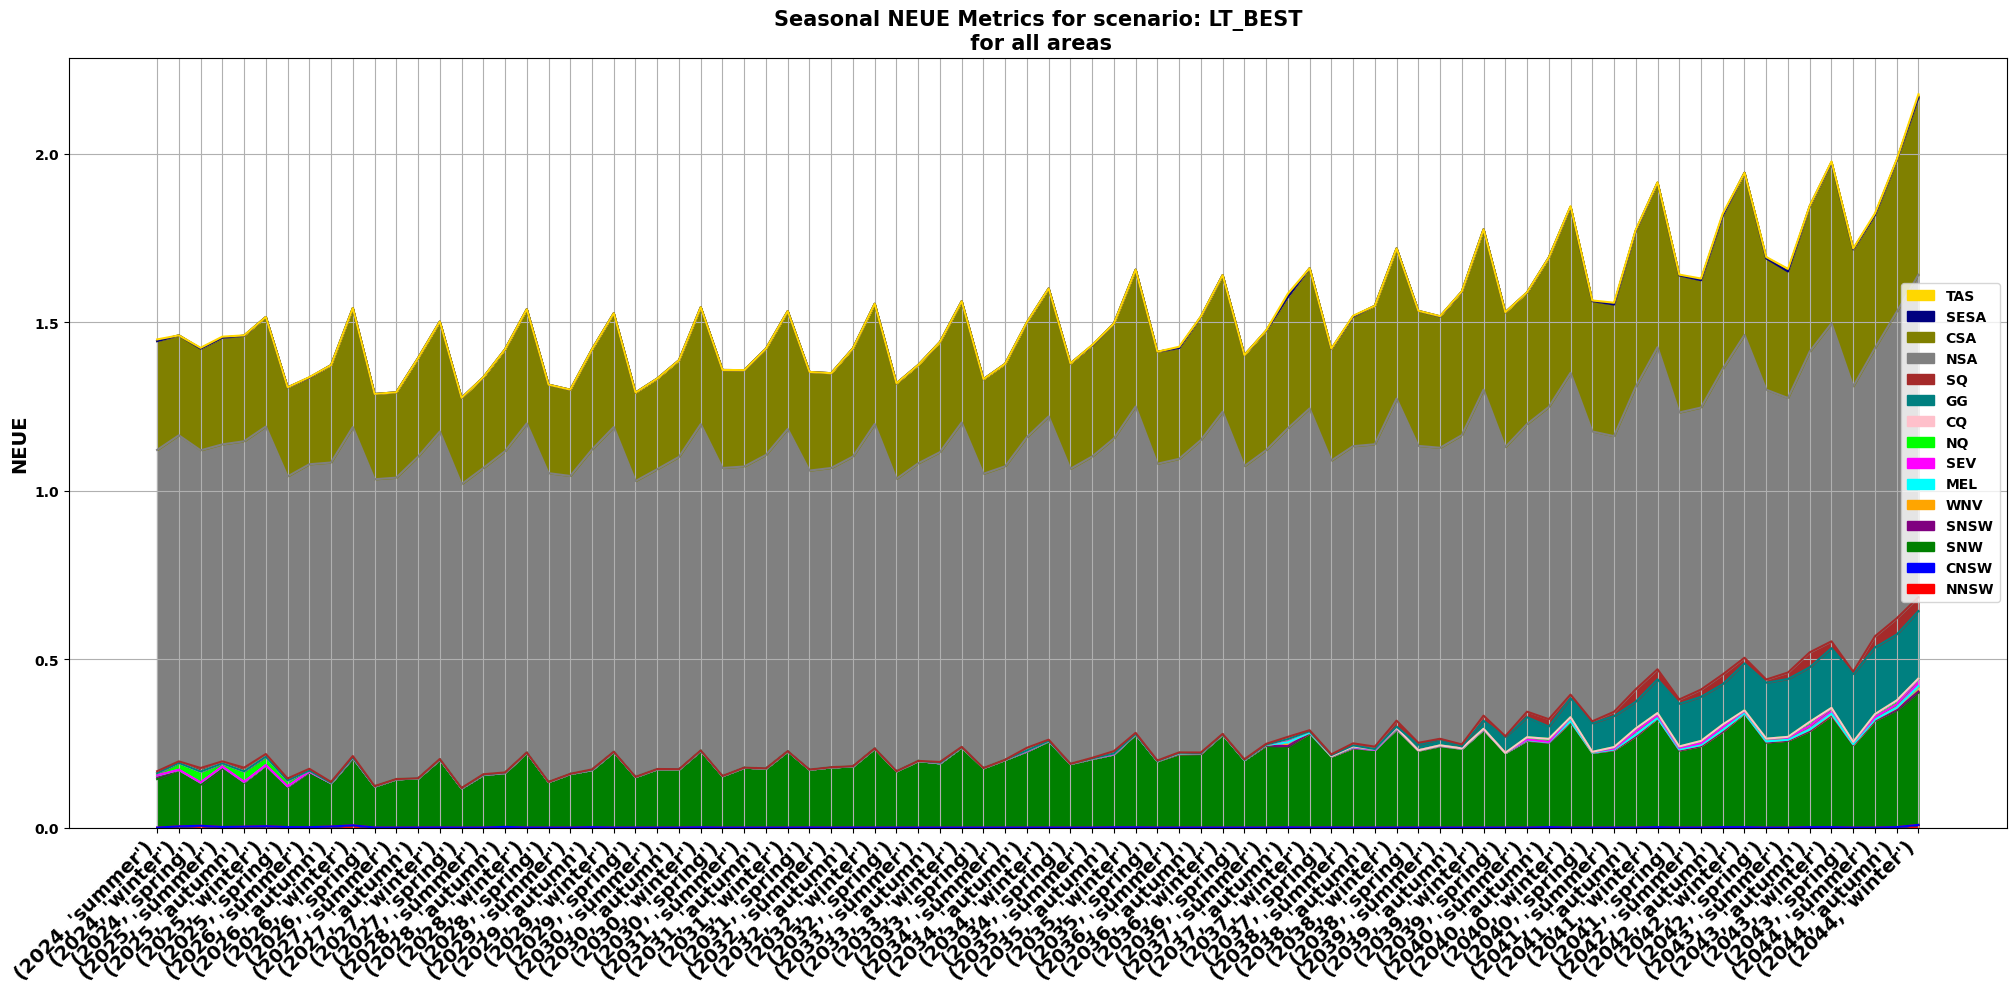

In [72]:
seasonal_data_LT_BEST = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

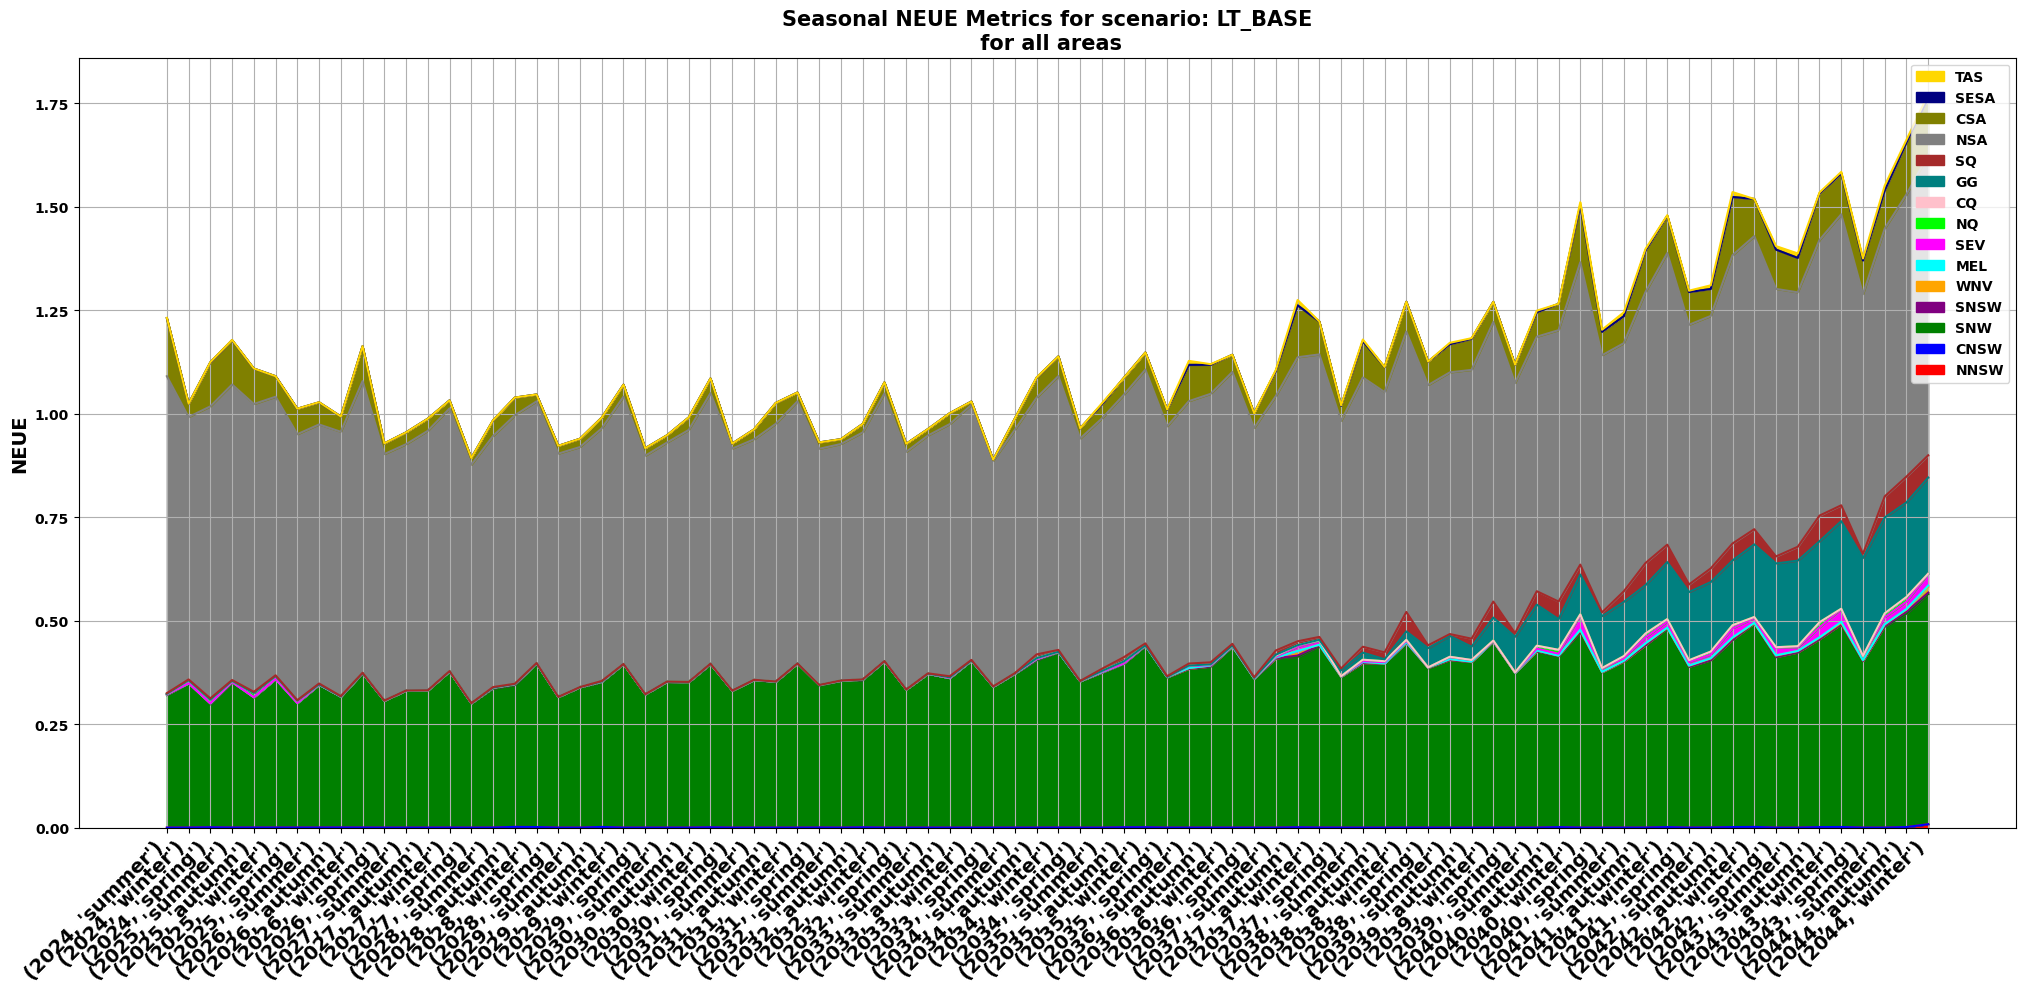

In [70]:
seasonal_data_LT_BASE = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

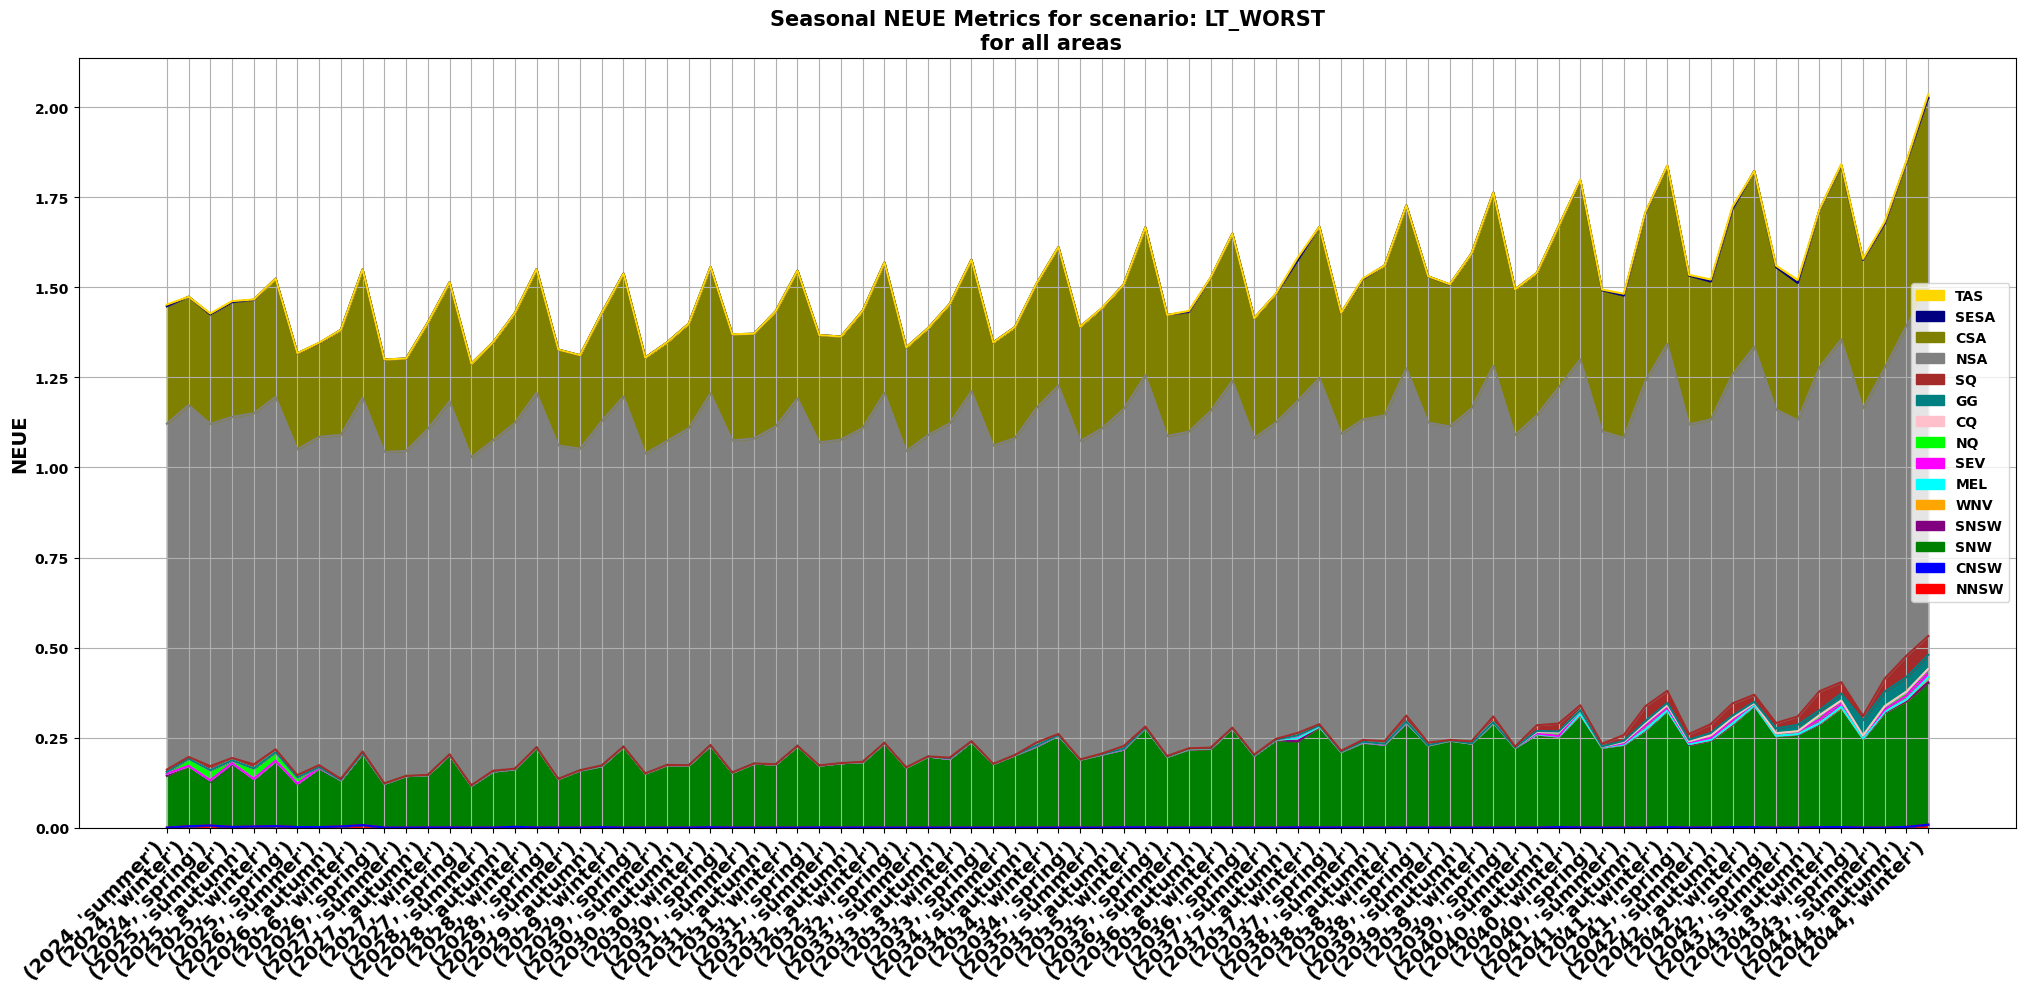

In [68]:
seasonal_data_LT_WORST = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

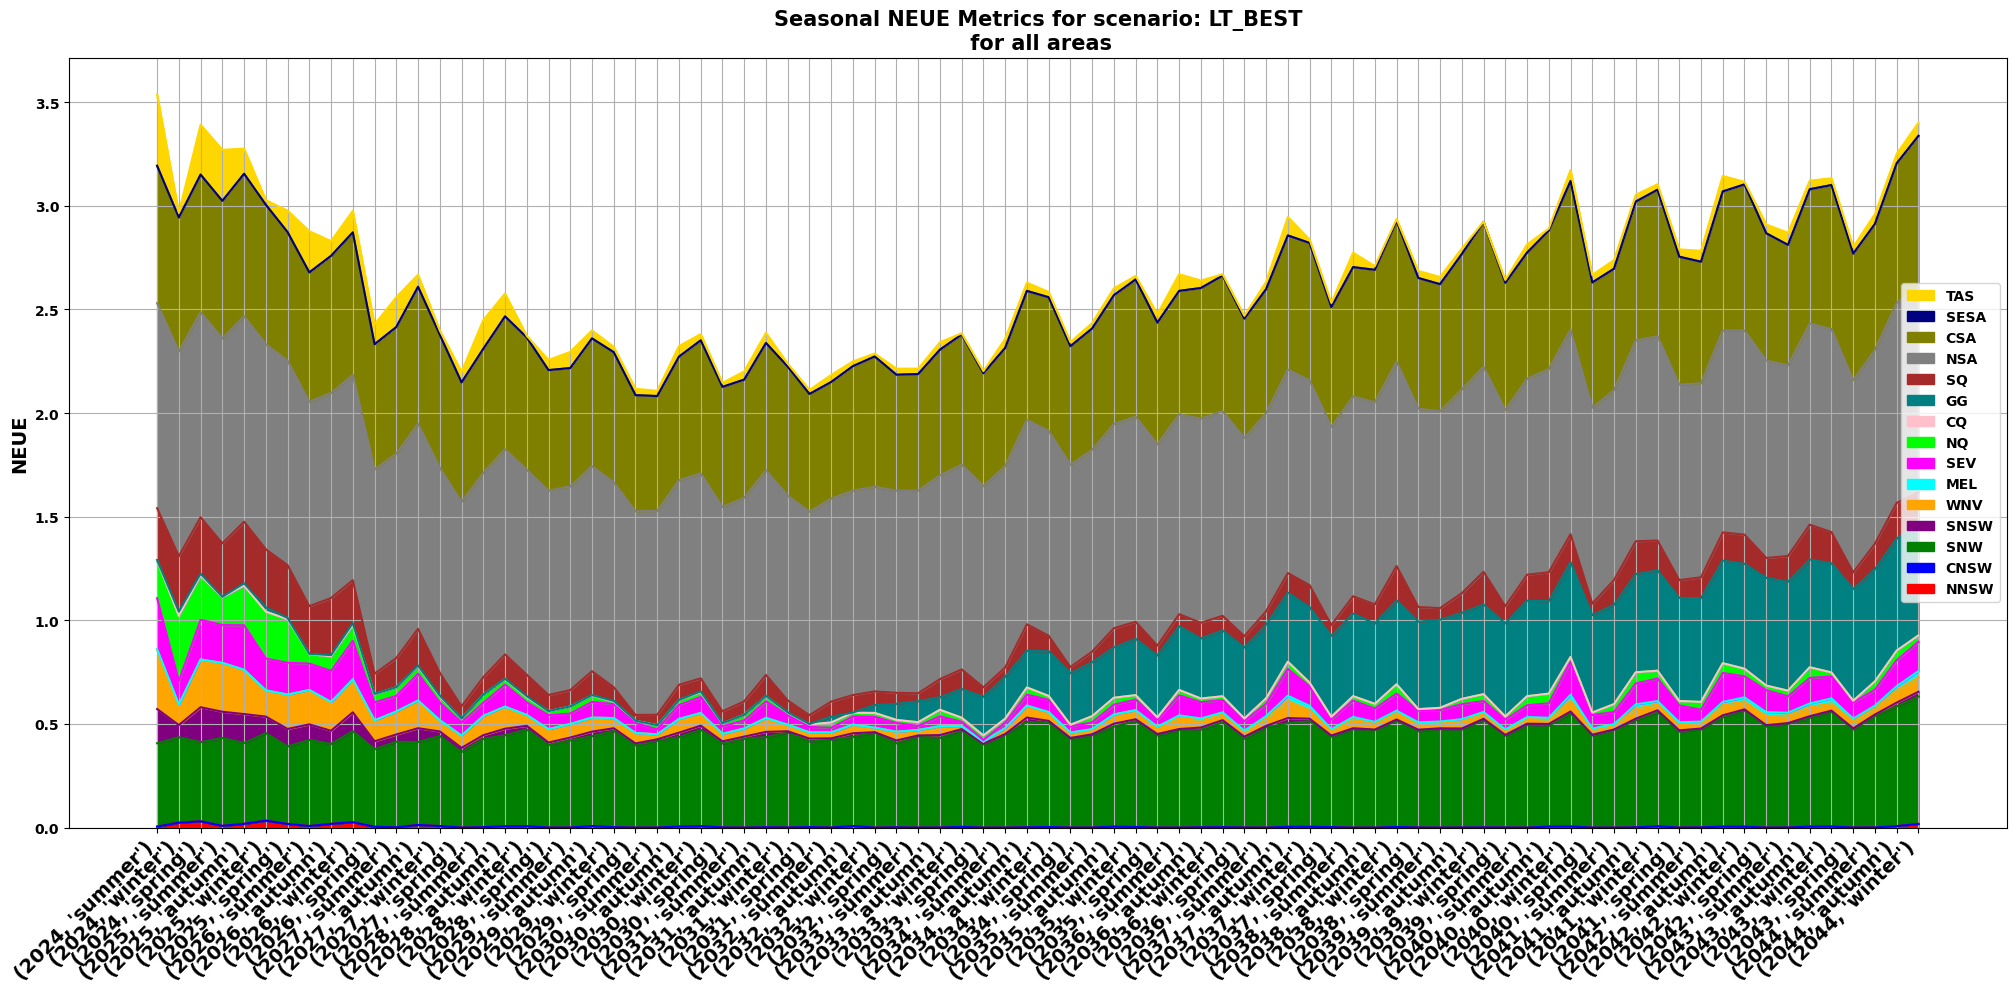

In [9]:
seasonal_data_LT_BEST = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

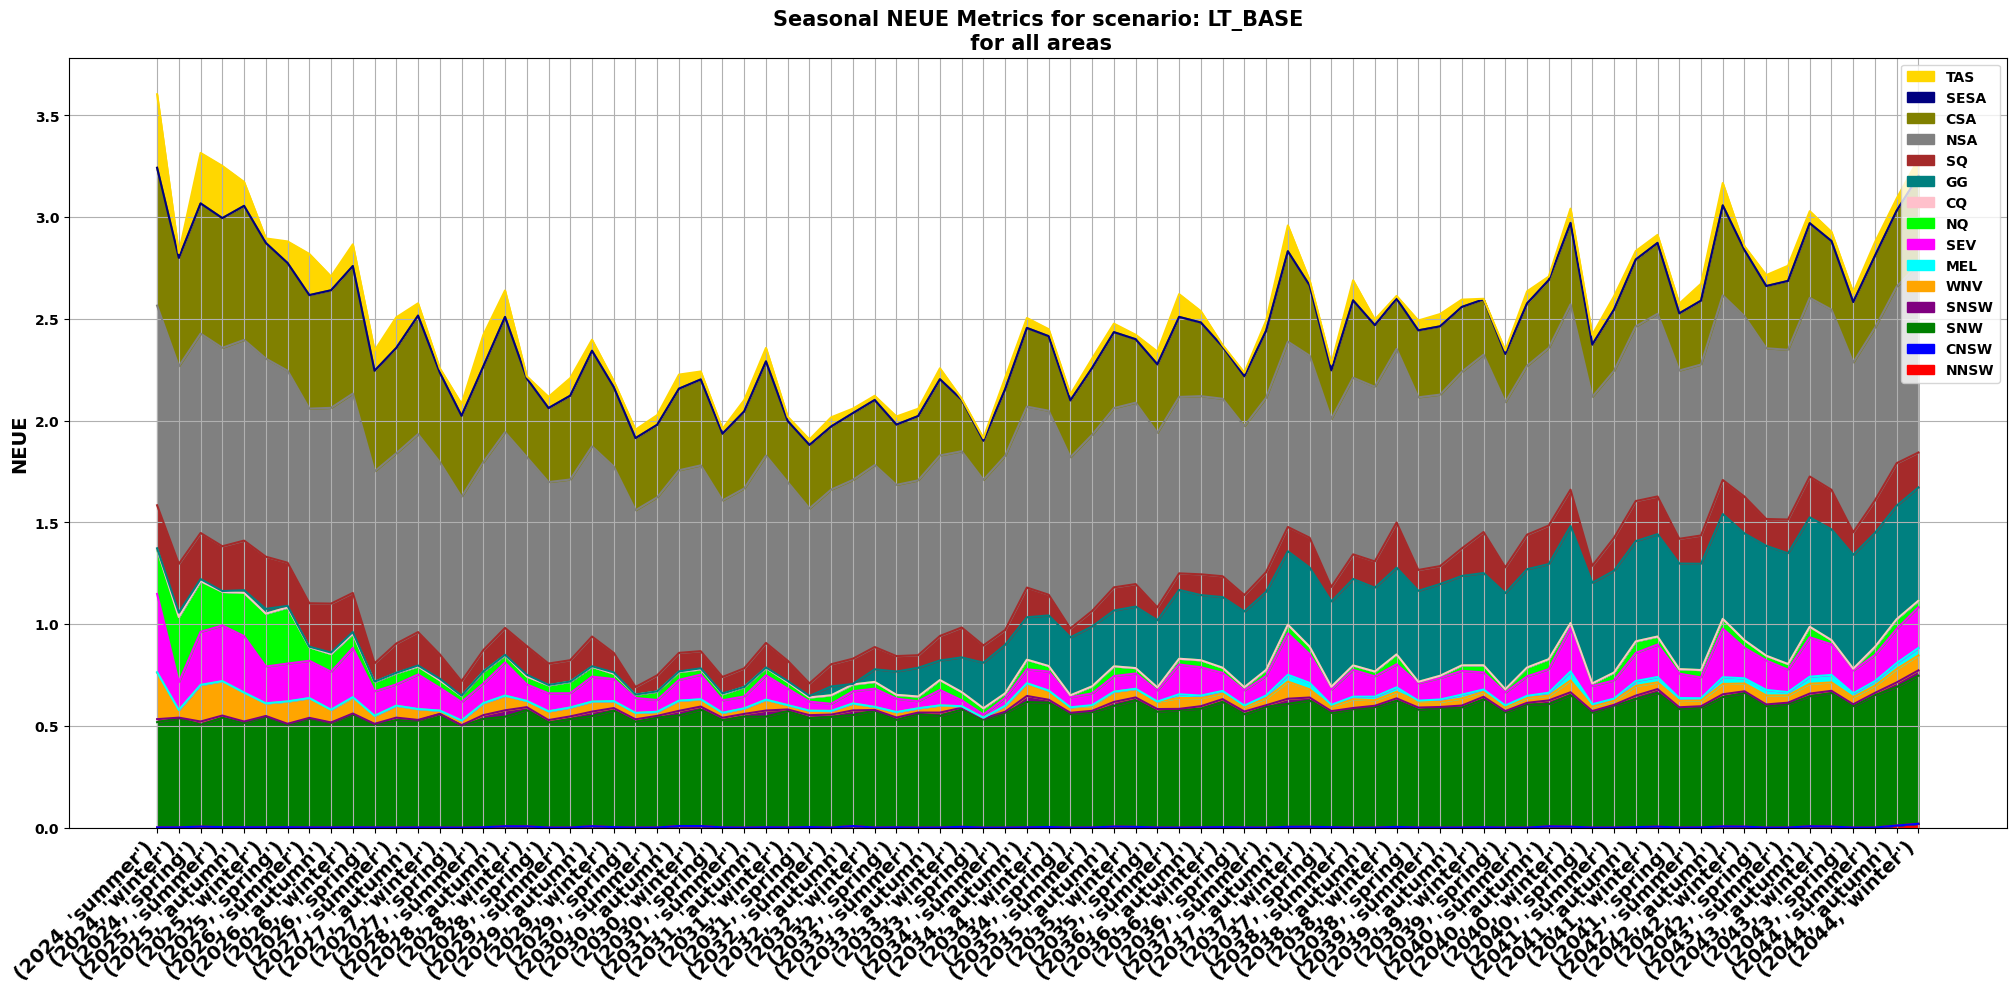

In [7]:
seasonal_data_LT_BASE = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

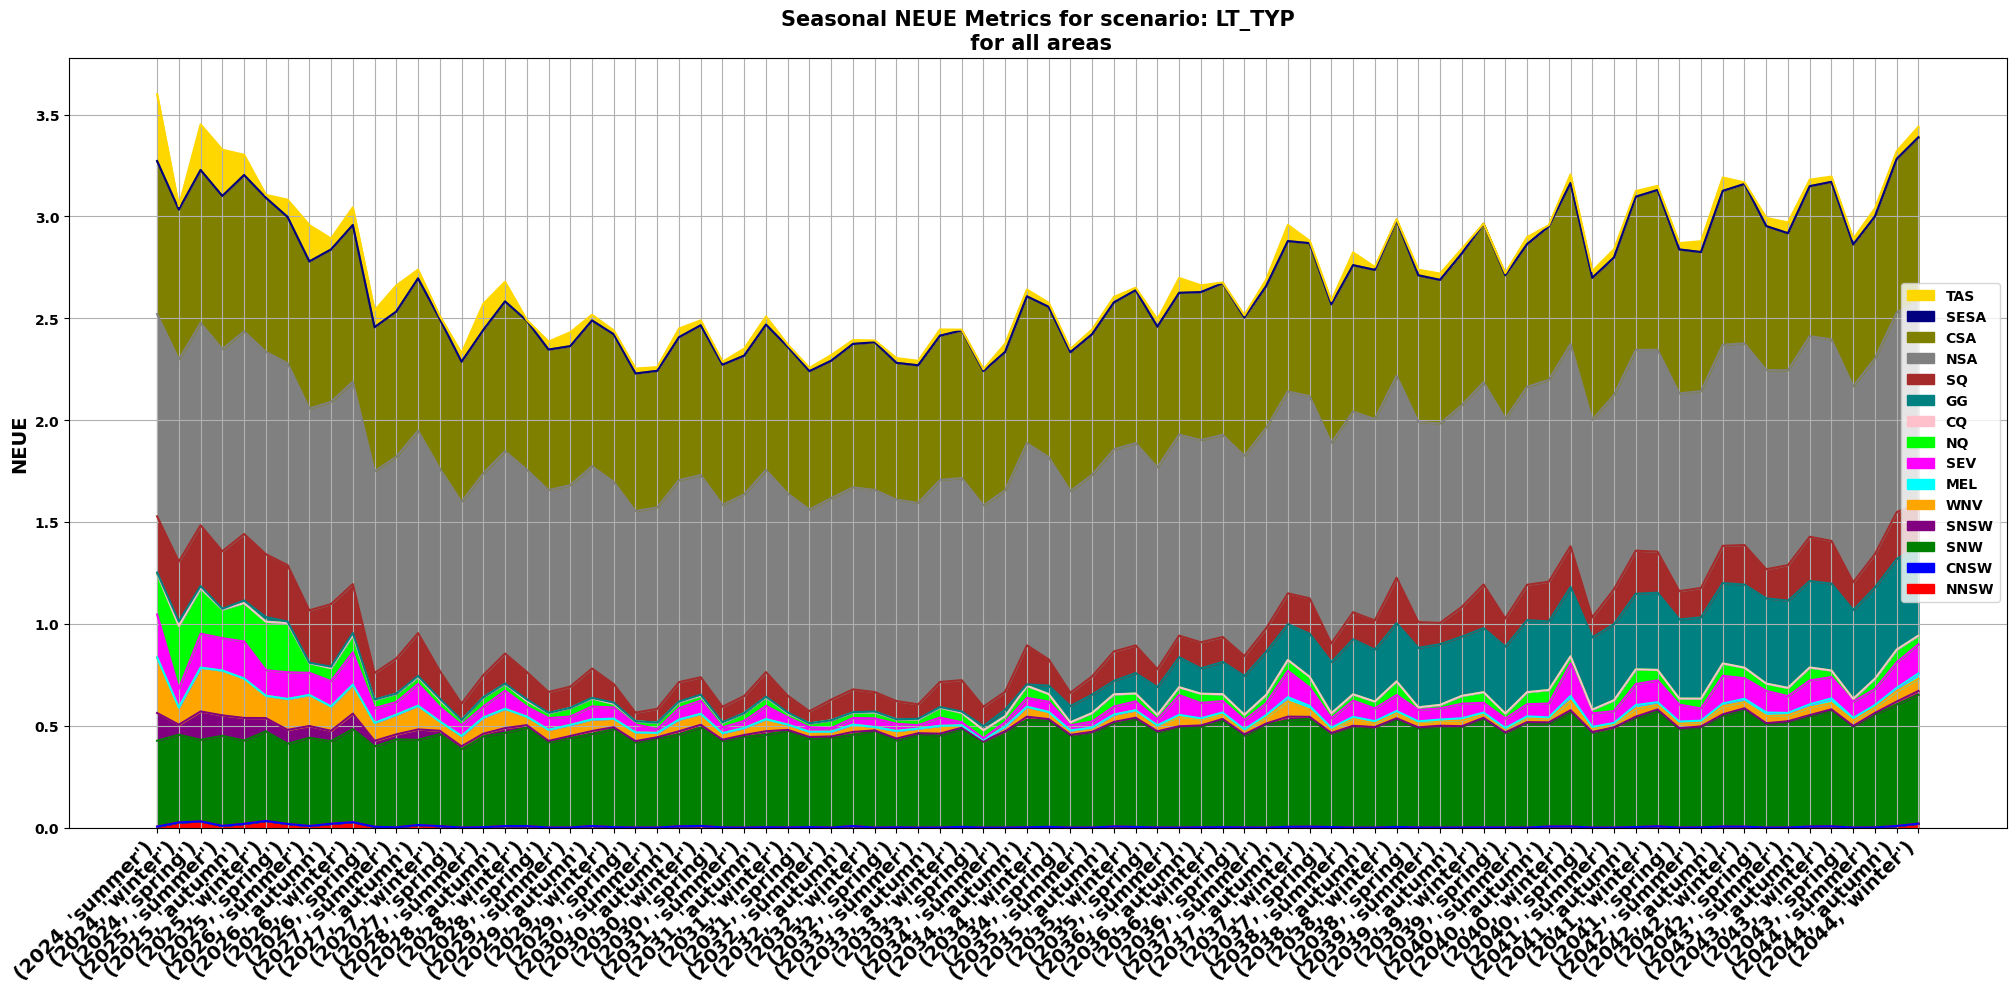

In [4]:
seasonal_data_LT_TYP = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

In [76]:
def plot_diff_baseline(best_baseline, worst_baseline, typ_baseline):
    best_baseline_15 = best_baseline[['CNSW', 'CSA', 'GG', 'MEL', 'NNSW', 'NQ', 'NSA', 
        'SESA', 'SEV', 'SNSW', 'SNW', 'SQ', 'TAS', 'VIC', 'WNV']]
    worst_baseline_15 = worst_baseline[['CNSW', 'CSA', 'GG', 'MEL', 'NNSW', 'NQ', 'NSA', 
        'SESA', 'SEV', 'SNSW', 'SNW', 'SQ', 'TAS', 'VIC', 'WNV']]
    typ_baseline_15 = typ_baseline[['CNSW', 'CSA', 'GG', 'MEL', 'NNSW', 'NQ', 'NSA', 
        'SESA', 'SEV', 'SNSW', 'SNW', 'SQ', 'TAS', 'VIC', 'WNV']]
    combined_diff = pd.concat([best_baseline_15.add_prefix('best_'), worst_baseline_15.add_prefix('worst_'), 
                           typ_baseline_15.add_prefix('typical_')], axis=1)
    data = combined_diff.columns.tolist()
    sorted_list = sorted(data, key=lambda x: x.split('_')[1])
    combined_diff = combined_diff[sorted_list]
    fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
# Use a diverging color map (e.g., 'coolwarm' or 'RdBu')
    cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7]) 
    sns.heatmap(combined_diff.T, cmap="RdBu_r", center=0, annot=False, ax=ax1,
           xticklabels=1, yticklabels=1, cbar_ax=cbar_ax)
    ax1.set_xlabel('')
    ax1.set_xticklabels(combined_diff.index.tolist(), fontweight='bold',
                        fontsize=14)
    ax1.set_yticklabels(combined_diff.T.index.tolist(), fontweight='bold',
                        fontsize=10)
#plt.tight_layout()
    fig.suptitle('Best, worst and typical variation in NEUE vs Baseline', weight="bold", fontsize=15)
    plt.show()

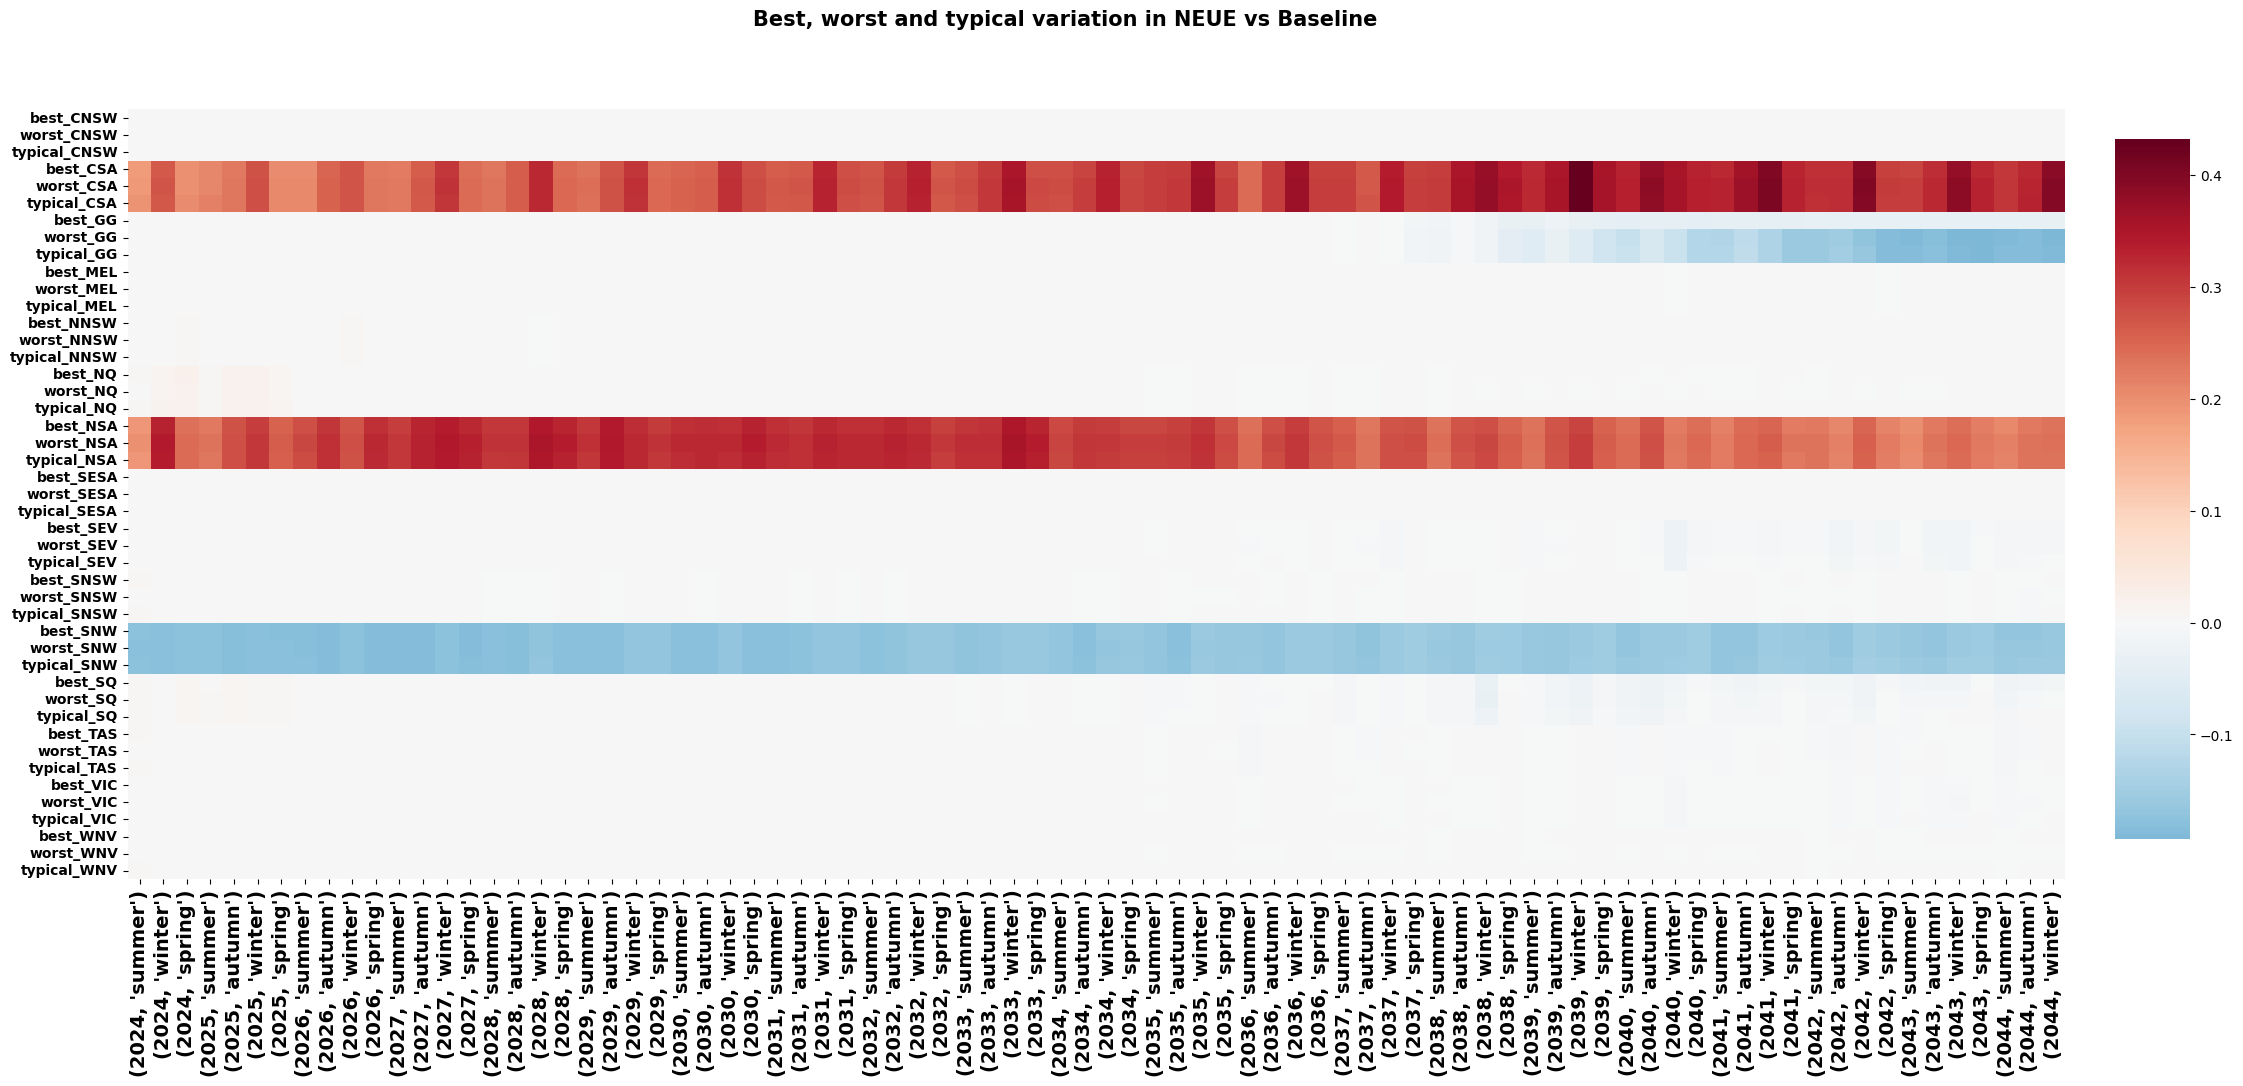

In [78]:
best_baseline =  seasonal_data_LT_BEST - seasonal_data_LT_BASE
worst_baseline = seasonal_data_LT_WORST - seasonal_data_LT_BASE
typ_baseline =  seasonal_data_LT_TYP - seasonal_data_LT_BASE
plot_diff_baseline(best_baseline, worst_baseline, typ_baseline)

scenario:  LT_BASE


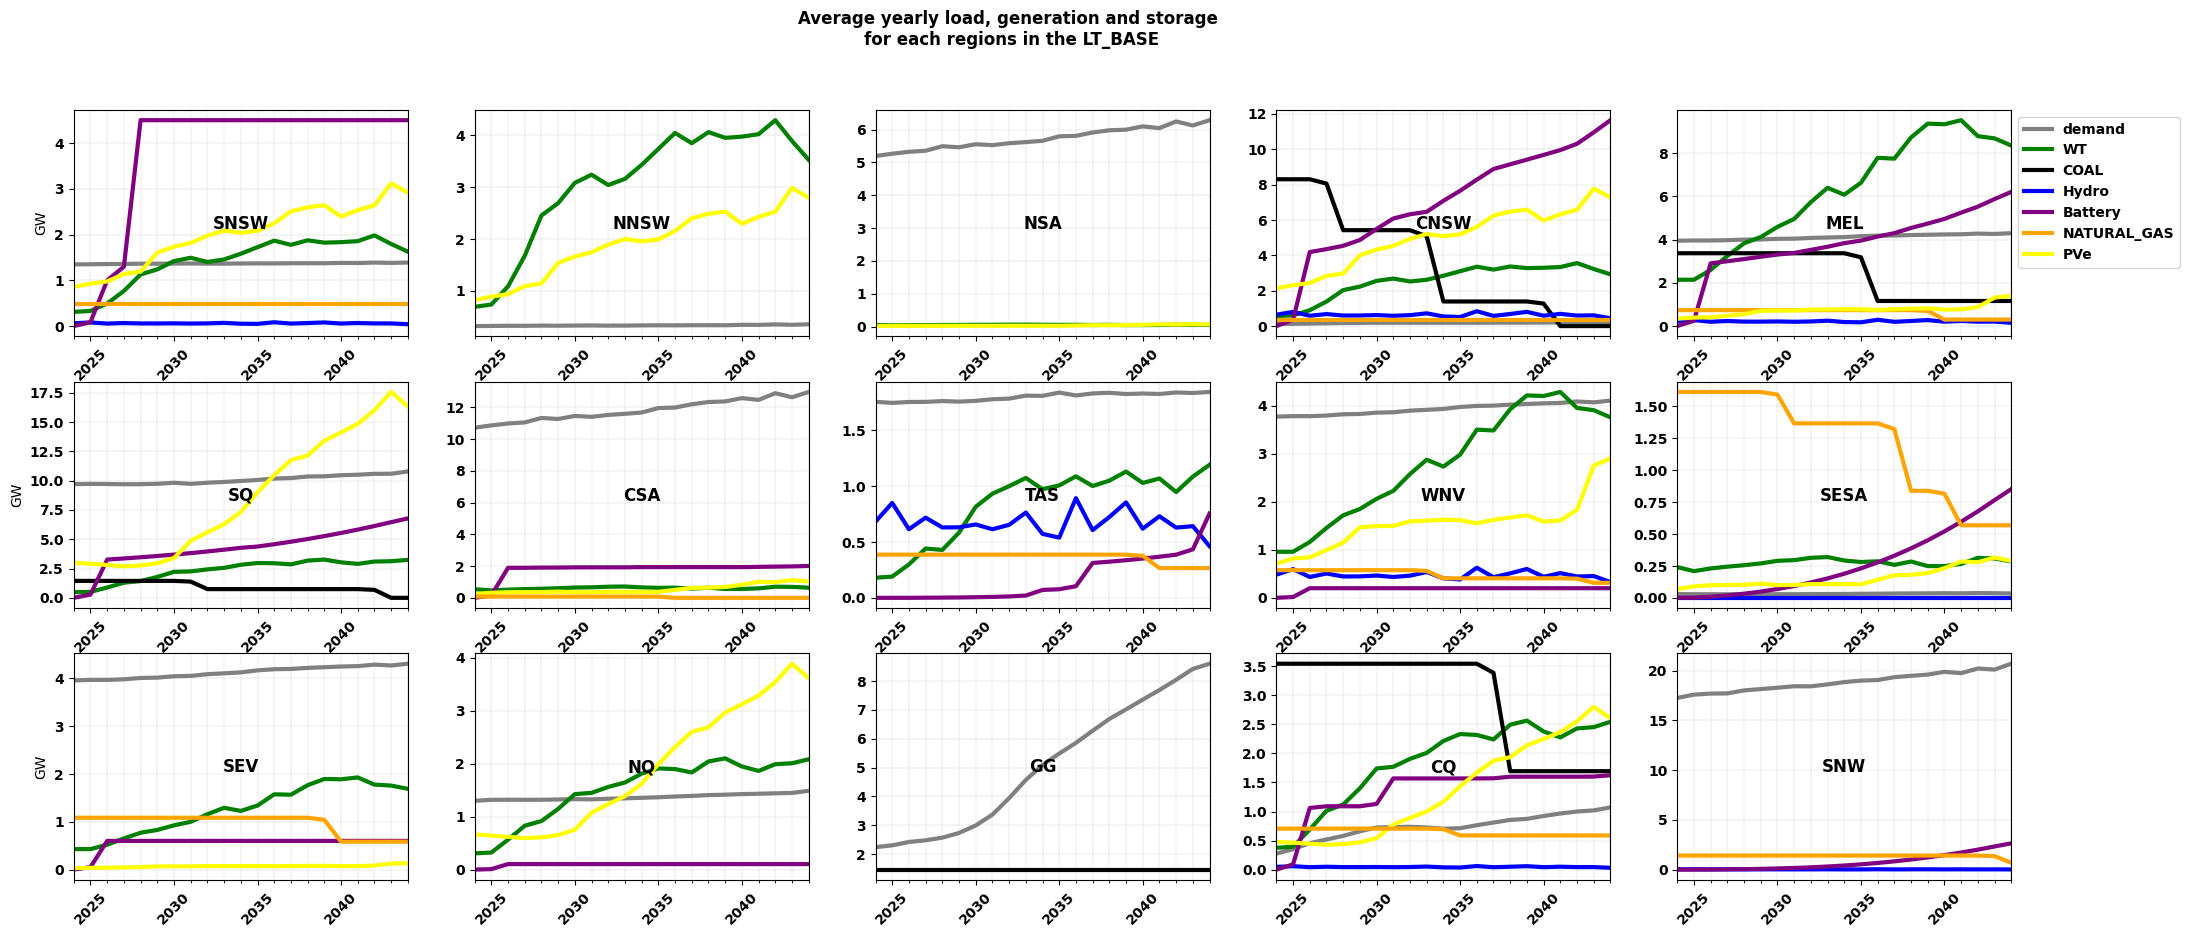

In [48]:
print("scenario: ", scenario)
resample="yearly"
load_gens_simu = get_data_simu(shortfall_data)
plot_yearly_rlg_v1(load_gens_simu, shortfall_data, resample, scenario)

### Get some stats on the pras lines and forward capacity of the interface



In [91]:
pras_lines = pd.read_csv("../data/output/pras_lines_LT_BASE.csv")
limits = pd.read_csv("../data/output/interface_forward_lines_LT_BASE.csv")
#pras_lines

In [93]:
limits

,region_from,region_to,forward
0,4,2,2861
1,4,5,2029
2,1,2,1474
3,1,11,1989
4,12,13,1442
5,2,3,6986
6,6,15,1500
7,6,5,15823
8,6,7,13238
9,11,9,21943


In [92]:
pras_lines

,name,ln_type,area_from,area_to,power
0,bus_1189-bus_1289-i_line_1189_to_1469_2_cp,ACLine,2,3,231.0
1,bus_1113-bus_2195-i_line_1113_to_2195_1_cp,ACLine,4,5,677.0
2,bus_2145-bus_2179-i_line_2145_to_2179_1_cp,ACLine,6,5,301.0
3,bus_2199-bus_2202-i_line_2199_to_2202_2_cp,ACLine,6,7,1498.0
4,bus_1110-bus_1140-i_line_1110_to_1511_1_cp,ACLine,2,3,877.0
...,...,...,...,...,...
93,bus_3607-bus_3624-i_line_3607_to_3624_2_cp,ACLine,10,9,676.0
94,bus_2105-bus_2106-i_connection V2_1,ACLine,6,5,1520.0
95,bus_1148-bus_2191-i_line_1148_to_2191_1_cp,ACLine,4,5,707.0
96,bus_1289-bus_1478-i_line_1391_to_1478_1_cp,ACLine,2,3,176.0
